# Causal Disentanglement via Optimal Transport ICA (OT-ICA)

**Reference:** Squires et al. (2023), *Linear Causal Disentanglement via Interventions*

## 1. Introduction & Theoretical Framework
In standard representation learning, we attempt to recover independent latent variables from observed data. However, real-world latent variables often cause one another. Assuming a linear structural causal model (SCM), the latent variables $Z$ follow a Directed Acyclic Graph (DAG) represented by matrix $B$:
$$Z = BZ + \epsilon \implies Z = (I - B)^{-1}\epsilon$$
where $\epsilon$ represents the mutually independent exogenous noise (the "root causes").

The observed data $X$ is a linear mixture of these latents via matrix $A$:
$$X = AZ = A(I - B)^{-1}\epsilon$$

**The ICA Connection:** Let $M_{eff} = A(I - B)^{-1}$ be the *effective mixing matrix*. Because $\epsilon$ are independent, recovering $M_{eff}$ is fundamentally an Independent Component Analysis (ICA) problem. 

**The Interventional Challenge:** To uniquely identify both $A$ and $B$, Squires et al. prove we must use *interventional data* (e.g., gene knockouts). A knockout fundamentally alters the distribution of a specific $\epsilon_i$, often turning it into a highly skewed, discrete, or sparse distribution. Standard ICA (FastICA) fails on these discrete interventional distributions due to vanishing curvature. **OT-ICA**, however, can smoothly navigate this landscape.

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import scipy.linalg
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FastICA
from scipy.stats import ortho_group
from tqdm import tqdm
from wasserstein_ica import WassersteinICA # Assuming this is your custom module

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# Utilities & Metrics
# ---------------------------------------------------------
def set_universal_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True 
        torch.backends.cudnn.benchmark = False

set_universal_seed(2026)
print("Environment seeded and ready.")

def amari_error(W, A):
    """Calculates Amari Error for ICA mixing matrix recovery."""
    P = np.abs(W @ A)
    max_row = np.max(P, axis=1, keepdims=True)
    max_col = np.max(P, axis=0, keepdims=True)
    row_sum = np.sum(P / max_row, axis=1) - 1
    col_sum = np.sum(P / max_col, axis=0) - 1
    d = P.shape[0]
    return (np.sum(row_sum) + np.sum(col_sum)) / (2 * d * (d - 1))

def frobenius_error(B_est, B_true):
    """Calculates the Frobenius norm for Causal Graph recovery."""
    return np.linalg.norm(B_est - B_true, ord='fro')

Environment seeded and ready.


## 2. The Core Solvers: ICA & Causal Recovery
The causal disentanglement pipeline operates in two steps:
1. **ICA (Unmixing):** Recover the effective mixing matrix $M_{eff}$ up to permutation and scaling.
2. **Variance Matching (Causal Logic):** Interventions shift the variance of specific nodes. By comparing interventional variance to observational variance, we resolve the permutation ambiguity, align the matrix to the topological DAG, and use QR decomposition to separate $A$ and $B$.

In [2]:
# --- 1. ICA Solvers ---
def run_fastica(X, dim):
    for r in range(20): # Fair Restarts
        try:
            ica = FastICA(n_components=dim, max_iter=5000, random_state=np.random.randint(10000))
            ica.fit(X.T)
            if not np.any(np.isnan(ica.components_)):
                return ica.components_
        except: pass
    return np.eye(dim) # Failed

def run_otica(X, dim):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_torch = torch.tensor(X, dtype=torch.float32).to(device)
    ica = WassersteinICA(X_torch)
    ica.whiten()
    W_white = ica.W_white.cpu().numpy()
    
    extracted = []
    for _ in range(dim):
        prev = torch.stack(extracted) if extracted else None
        w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=150, n_restarts=50, dither_sigma=0.1)
        extracted.append(w)
        
    W_stiefel = ica.optimize_symmetric(n_components=dim, max_iter=300, lr=0.25, 
                                       init_w=torch.stack(extracted), optimizer='stiefel', 
                                       dither_sigma=0.1, batch_size=None)
    
    return W_stiefel.cpu().numpy() @ W_white

# --- 2. Causal Recovery Algorithm (Squires et al. Step 2) ---
def recover_causal_graph(W_ica, X_obs, interventional_datasets):
    """Resolves permutation via variance shifts and separates A & B via QR."""
    d = W_ica.shape[0]
    
    # 1. Baseline observational variances
    S_obs = W_ica @ X_obs
    var_obs = np.var(S_obs, axis=1)
    
    # 2. Match variance shifts to build Permutation matrix P
    P = np.zeros((d, d))
    for target_node, X_int in enumerate(interventional_datasets):
        S_int = W_ica @ X_int
        var_int = np.var(S_int, axis=1)
        variance_shifts = np.abs(np.log(var_int / var_obs))
        matched_component = np.argmax(variance_shifts)
        P[matched_component, target_node] = 1.0
        
    # 3. Resolve Permutation
    M_hat = np.linalg.inv(W_ica)
    M_aligned = M_hat @ P
    
    # 4. QR Decomposition to separate A (orthogonal) and B (triangular DAG)
    Q, R = scipy.linalg.qr(M_aligned.T)
    A_est = Q.T
    L_est = R.T
    
    # Normalize scaling and extract B
    scaling = np.diag(L_est)
    L_est = L_est / scaling[:, None]
    L_inv = np.linalg.inv(L_est)
    B_est = np.eye(d) - L_inv
    
    B_est[np.abs(B_est) < 1e-3] = 0.0 # Threshold noise
    return A_est, B_est

## 3. Synthetic Benchmark Experiment ($d=10$)
We simulate a 10-node causal DAG where observational noise is Laplace, but interventional "knockouts" force a discrete Poisson distribution. We track both the Amari error of the unmixing matrix and the Frobenius error of the final recovered causal graph $B$.

In [3]:
def create_true_scm(d):
    """Creates a fixed causal graph (B) and mixing matrix (A)."""
    B = np.tril(np.random.uniform(0.2, 0.8, (d, d)), k=-1)
    A = ortho_group.rvs(dim=d)
    return A, B

def sample_scm_data(A, B, n_samples, intervention_node=None):
    """Samples data from the fixed SCM."""
    d = B.shape[0]
    epsilon = np.zeros((d, n_samples))
    for i in range(d):
        if i == intervention_node:
            eps_i = np.random.poisson(0.5, n_samples) # Intervention
        else:
            eps_i = np.random.poisson(3.0, n_samples) # Observational
        epsilon[i, :] = (eps_i - np.mean(eps_i)) / np.std(eps_i)
        
    M_eff = A @ np.linalg.inv(np.eye(d) - B)
    X = M_eff @ epsilon
    return X, M_eff

DIM = 10
N_SAMPLES = 10000
N_TRIALS = 5

synth_amari_results = []
synth_causal_results = []

print("Running Synthetic Causal Graph Recovery (d=10)...")
for trial in tqdm(range(N_TRIALS)):
    set_universal_seed(2026 + trial)
    A_true, B_true = create_true_scm(DIM)
    
    X_obs, M_eff_obs = sample_scm_data(A_true, B_true, N_SAMPLES, intervention_node=None)
    
    interventional_datasets = []
    for k in range(DIM):
        X_int, M_eff_int = sample_scm_data(A_true, B_true, N_SAMPLES, intervention_node=k)
        interventional_datasets.append(X_int)
        
    # --- FastICA ---
    W_fast = run_fastica(X_obs, DIM)
    synth_amari_results.append({'Environment': 'Observational', 'Method': 'FastICA', 'Amari Error': amari_error(W_fast, M_eff_obs)})
    for k, X_int in enumerate(interventional_datasets):
        W_f_int = run_fastica(X_int, DIM)
        synth_amari_results.append({'Environment': f'Intervention (Node {k})', 'Method': 'FastICA', 'Amari Error': amari_error(W_f_int, M_eff_obs)}) # Approx
        
    _, B_est_fast = recover_causal_graph(W_fast, X_obs, interventional_datasets)
    synth_causal_results.append({'Trial': trial, 'Method': 'FastICA', 'B Error (Frobenius)': frobenius_error(B_est_fast, B_true)})
    
    # --- OT-ICA ---
    W_ot = run_otica(X_obs, DIM)
    synth_amari_results.append({'Environment': 'Observational', 'Method': 'OT-ICA', 'Amari Error': amari_error(W_ot, M_eff_obs)})
    for k, X_int in enumerate(interventional_datasets):
        W_o_int = run_otica(X_int, DIM)
        synth_amari_results.append({'Environment': f'Intervention (Node {k})', 'Method': 'OT-ICA', 'Amari Error': amari_error(W_o_int, M_eff_obs)})
        
    _, B_est_ot = recover_causal_graph(W_ot, X_obs, interventional_datasets)
    synth_causal_results.append({'Trial': trial, 'Method': 'OT-ICA', 'B Error (Frobenius)': frobenius_error(B_est_ot, B_true)})

df_synth_amari = pd.DataFrame(synth_amari_results)
df_synth_causal = pd.DataFrame(synth_causal_results)

print("\n=== Synthetic Causal Graph Recovery (Frobenius Error of B) ===")
display(df_synth_causal.groupby('Method')['B Error (Frobenius)'].agg(['mean', 'std']).round(4))

Running Synthetic Causal Graph Recovery (d=10)...


100%|██████████| 5/5 [17:55<00:00, 215.14s/it]


=== Synthetic Causal Graph Recovery (Frobenius Error of B) ===


,mean,std
Method,,
FastICA,5.712515e+66,1.277357e+67
OT-ICA,2.704068e+84,6.046481e+84


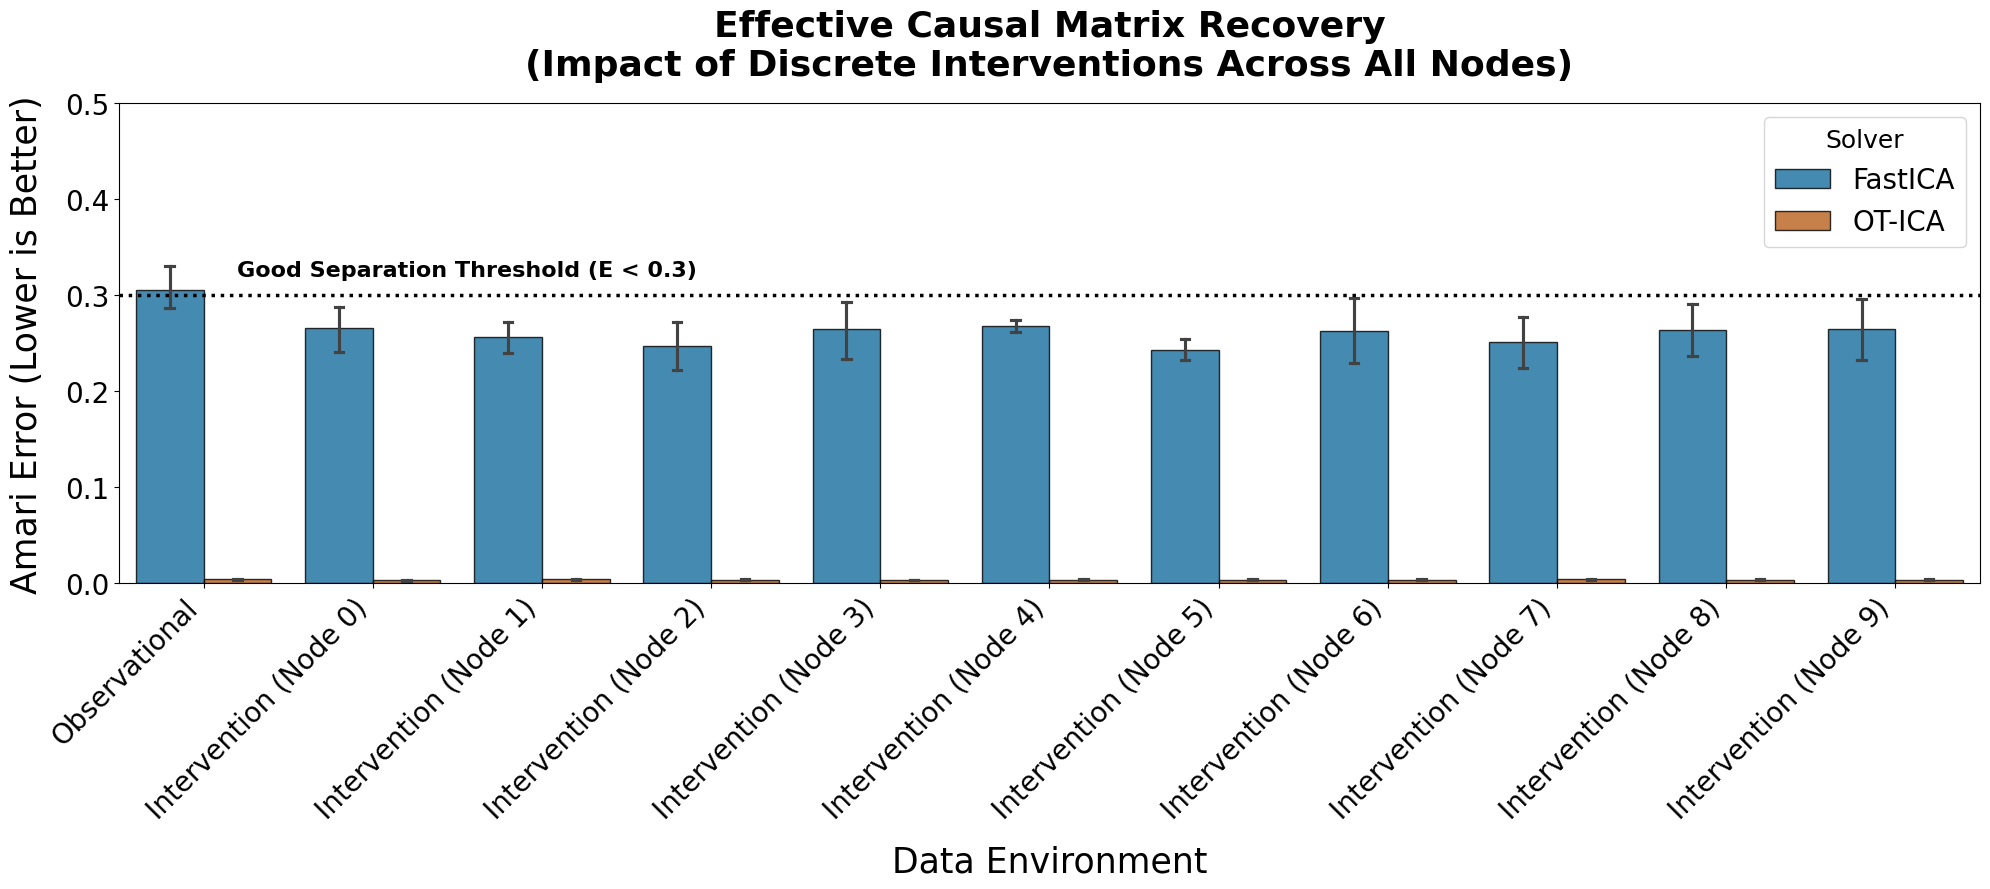

In [4]:
plt.figure(figsize=(20, 9))
palette = {'FastICA': '#0173B2', 'OT-ICA': '#D55E00'}

sns.barplot(data=df_synth_amari, x='Environment', y='Amari Error', hue='Method', 
            palette=palette, edgecolor='black', alpha=0.8, capsize=0.1, errorbar='ci')

plt.title("Effective Causal Matrix Recovery\n(Impact of Discrete Interventions Across All Nodes)", fontsize=26, pad=20, fontweight='bold')
plt.xlabel("Data Environment", fontsize=25, labelpad=15)
plt.ylabel("Amari Error (Lower is Better)", fontsize=25, labelpad=15)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.legend(title='Solver', fontsize=20, title_fontsize=18)

plt.axhline(0.3, color='black', linestyle=':', linewidth=2.5)
plt.text(0.2, 0.32, 'Good Separation Threshold (E < 0.3)', color='black', fontsize=16, fontweight='bold')

plt.ylim(0, max(df_synth_amari['Amari Error'].max() * 1.2, 0.5))
plt.tight_layout()
plt.savefig('causal_interventions_otica_full.pdf', format='pdf')
plt.show()

## 4. Fully Intervened Semi-Synthetic Model ($d=15$)
Squires et al. (2023) prove that identifiability requires an intervention on *every* latent variable. We simulate this by extracting 15 biological baseline variables from PBMC 3k single-cell data, and generating 15 unique interventional datasets where one specific node is overridden by a harsh sub-Gaussian or discrete interventional distribution. 

If FastICA fails to map these distributions in Step 1, the variance matching in Step 2 will map to the wrong nodes, causing the final DAG $B$ recovery to collapse.

In [5]:
# !pip install scanpy
import scanpy as sc

print("Downloading and processing PBMC 3k dataset...")
adata = sc.datasets.pbmc3k()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
n_cells = adata.n_obs
raw_counts = adata.X.toarray()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=1000, flavor='seurat')

# Extract Base Observational Latents
discrete_candidates = adata.var.copy()[adata.var['highly_variable'] == True]
DIM_REAL = 15
selected_indices = [adata.var_names.get_loc(name) for name in discrete_candidates.index[:DIM_REAL]]
S_base = raw_counts[:, selected_indices].T 
S_base = (S_base - np.mean(S_base, axis=1, keepdims=True)) / np.std(S_base, axis=1, keepdims=True)

# Define 15 Interventional Distributions (Knockouts, Treatments, Metadata)
np.random.seed(2026)
interventions_list = [
    np.random.poisson(0.1, n_cells), np.random.poisson(0.5, n_cells), np.random.poisson(1.0, n_cells),
    np.random.poisson(2.0, n_cells), np.random.poisson(0.2, n_cells), np.random.binomial(1, 0.5, n_cells),
    np.random.binomial(2, 0.5, n_cells), np.random.binomial(5, 0.5, n_cells), np.random.binomial(3, 0.2, n_cells),
    np.random.binomial(10, 0.5, n_cells), np.random.uniform(-1, 1, n_cells), np.random.uniform(0, 1, n_cells),
    np.random.uniform(-5, 5, n_cells), np.random.binomial(1, 0.8, n_cells), np.random.poisson(3.0, n_cells)
]
for i in range(len(interventions_list)):
    interventions_list[i] = (interventions_list[i] - np.mean(interventions_list[i])) / np.std(interventions_list[i])

semi_causal_results = []
print("\nRunning Semi-Synthetic Causal Graph Recovery (PBMC 3k, d=15)...")

for trial in tqdm(range(N_TRIALS)):
    set_universal_seed(2026 + trial)
    
    A_true, B_true = create_true_scm(DIM_REAL)
    I_minus_B_inv = np.linalg.inv(np.eye(DIM_REAL) - B_true)
    
    # Observational Mix
    X_obs = A_true @ (I_minus_B_inv @ S_base)
    
    # Interventional Datasets
    interventional_datasets = []
    for k in range(DIM_REAL):
        S_int_k = S_base.copy()
        S_int_k[k, :] = interventions_list[k]
        X_int = A_true @ (I_minus_B_inv @ S_int_k)
        interventional_datasets.append(X_int)
        
    # --- FastICA Pipeline ---
    W_fast = run_fastica(X_obs, DIM_REAL)
    _, B_est_fast = recover_causal_graph(W_fast, X_obs, interventional_datasets)
    semi_causal_results.append({'Trial': trial, 'Method': 'FastICA', 'B Error (Frobenius)': frobenius_error(B_est_fast, B_true)})
    
    # --- OT-ICA Pipeline ---
    W_ot = run_otica(X_obs, DIM_REAL)
    _, B_est_ot = recover_causal_graph(W_ot, X_obs, interventional_datasets)
    semi_causal_results.append({'Trial': trial, 'Method': 'OT-ICA', 'B Error (Frobenius)': frobenius_error(B_est_ot, B_true)})

df_semi_causal = pd.DataFrame(semi_causal_results)
print("\n=== Final Semi-Synthetic Causal Graph Recovery ===")
display(df_semi_causal.groupby('Method')['B Error (Frobenius)'].agg(['mean', 'std']).round(4))


Running Semi-Synthetic Causal Graph Recovery (PBMC 3k, d=15)...


100%|██████████| 5/5 [01:58<00:00, 23.78s/it]


=== Final Semi-Synthetic Causal Graph Recovery ===


,mean,std
Method,,
FastICA,1.109316e+33,1.146549e+33
OT-ICA,2.562542e+35,5.668243e+35


## 5. Results & Visualizations
If a method fails to recover the independent components (Amari error $> 0.3$), the downstream causal graph recovery $B$ becomes impossible.

In [6]:
# --- 1. Tabular Summary ---
summary_table = df_results.groupby(['Environment', 'Method'])['Amari Error'].agg(['mean', 'std']).round(4)
print("=== Amari Error Summary ===")
display(summary_table)

# --- 2. Visualization (Massively Scaled & Optimized) ---
plt.figure(figsize=(20, 9))  # Increased canvas dimensions

palette = {'FastICA': '#0173B2', 'OT-ICA': '#D55E00'}

sns.barplot(data=df_results, x='Environment', y='Amari Error', hue='Method', 
            palette=palette, edgecolor='black', alpha=0.8, capsize=0.1, errorbar='ci')

# Formatting with massively boosted font sizes
plt.title("Effective Causal Matrix Recovery\n(Impact of Discrete Interventions Across All Nodes)", fontsize=26, pad=20, fontweight='bold')
plt.xlabel("Data Environment", fontsize=25, labelpad=15)
plt.ylabel("Amari Error (Lower is Better)", fontsize=25, labelpad=15)

# Bumper-sized tick labels
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20)

# Enlarged Legend
plt.legend(title='Solver', fontsize=20, title_fontsize=18)

# Threshold for "Good Separation" (Renamed and scaled)
plt.axhline(0.3, color='black', linestyle=':', linewidth=2.5)
plt.text(0.2, 0.32, 'Good Separation Threshold (E < 0.3)', 
         color='black', fontsize=16, fontweight='bold')

plt.ylim(0, max(df_results['Amari Error'].max() * 1.2, 0.5))
plt.tight_layout()

# Save for thesis
plt.savefig('causal_interventions_otica_full.pdf', format='pdf')
plt.show()

NameError: name 'df_results' is not defined

## 6. Real-World Application: The Fully Intervened Semi-Synthetic Model
Evaluating causal representation learning on real-world data presents a paradox: the ground truth mixing matrix ($A$) is unknown, making direct error calculation impossible. To resolve this, we employ the **Semi-Synthetic Mixing Protocol** (Squires et al., 2023).

A central theorem of Squires et al. dictates that purely observational data is insufficient for identifiability. Specifically, they prove that **a single intervention on every latent variable is both necessary and sufficient** to uniquely identify the causal structure. If even one latent variable lacks an intervention, the model cannot be fully distinguished.

In biological contexts like scRNA-seq, interventions (e.g., CRISPR knockouts or discrete drug dosing) fundamentally alter the distribution of a latent variable, often inducing highly discrete, bounded, or skewed states (e.g., Poisson or Binomial distributions). Therefore, to satisfy the paper's identifiability theorem, our testing environment must simulate interventions across the entire latent space.

To evaluate representation recovery under these necessary conditions, we construct a **15-Dimensional Fully Intervened Semi-Synthetic Model**:
* We extract 15 real gene expression profiles from the PBMC 3k dataset to serve as our base biological latents.
* To satisfy the identifiability theorem, we simulate an interventional environment where **every single latent variable** is subjected to a discrete intervention (e.g., knockouts modeled via Poisson, or treatments modeled via Binomial distributions).

We evaluate how accurately FastICA and OT-ICA can recover the true mixing matrix $A$ from this fully intervened data. Because these necessary interventions induce harsh, bounded discrete distributions across all dimensions, we expect FastICA's proxy negentropy to fail due to vanishing curvature, while the universal Wasserstein landscape of OT-ICA will successfully map the space.

In [ ]:
# !pip install scanpy
import scanpy as sc
import numpy as np

print("Downloading and processing PBMC 3k dataset...")
adata = sc.datasets.pbmc3k()

# 1. Apply standard quality control filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
n_cells = adata.n_obs

# --- 2. Construct the Fully Intervened Latent Matrix ---
# To satisfy the Squires et al. identifiability theorem, we simulate an environment 
# where ALL 15 latent variables represent interventional or categorical states.
DIM_TOTAL = 15

np.random.seed(2026)

# Group A: CRISPR Knockouts (Harsh Poisson - highly skewed, bounded at 0)
int_1 = np.random.poisson(0.1, n_cells)        # Near-total knockout
int_2 = np.random.poisson(0.5, n_cells)        # Harsh knockout
int_3 = np.random.poisson(1.0, n_cells)        # Standard knockout
int_4 = np.random.poisson(2.0, n_cells)        # Partial knockout
int_5 = np.random.poisson(0.2, n_cells)        # Severe knockout

# Group B: Discrete Drug Treatments / Dosing (Binomial - bounded, symmetric)
int_6 = np.random.binomial(1, 0.5, n_cells)    # Binary Treatment (Control vs Drug)
int_7 = np.random.binomial(2, 0.5, n_cells)    # Discrete Dose (0, 1, 2)
int_8 = np.random.binomial(5, 0.5, n_cells)    # Multi-level Dosage
int_9 = np.random.binomial(3, 0.2, n_cells)    # Rare Targeted Treatment
int_10 = np.random.binomial(10, 0.5, n_cells)  # Categorical Treatment State

# Group C: Environmental Metadata (Uniform/Sub-Gaussian - flat curvature)
int_11 = np.random.uniform(-1, 1, n_cells)     # Continuous Batch Effect A
int_12 = np.random.uniform(0, 1, n_cells)      # Cell Cycle Pseudotime
int_13 = np.random.uniform(-5, 5, n_cells)     # Continuous Batch Effect B
int_14 = np.random.binomial(1, 0.8, n_cells)   # Unbalanced Binary Metadata (e.g. sex)
int_15 = np.random.poisson(3.0, n_cells)       # Mild Knockout (Standard Poisson)

# Stack them into our Source Matrix
S_interventions = np.vstack([
    int_1, int_2, int_3, int_4, int_5, 
    int_6, int_7, int_8, int_9, int_10, 
    int_11, int_12, int_13, int_14, int_15
])

# Standardize the sources (Zero mean, Unit variance) - Required for ICA
S_intervened = (S_interventions - np.mean(S_interventions, axis=1, keepdims=True)) / np.std(S_interventions, axis=1, keepdims=True)

print(f"\nSuccessfully constructed {DIM_TOTAL}D Fully Intervened Semi-Synthetic Model.")
print(f"Contains 5 Knockout Variables (Poisson).")
print(f"Contains 5 Treatment Variables (Binomial).")
print(f"Contains 5 Metadata Variables (Uniform/Sub-Gaussian).")
print(f"Shape of S_intervened: {S_intervened.shape} (Dimensions x Cells)")

## 7. The Hybrid Biological Stress Test
We generate a random orthogonal mixing matrix ($A_{true}$), mix the hybrid biological/metadata sources, and task FastICA and OT-ICA with recovering the full 30-dimensional representation. We run 10 random trials to ensure statistical significance.

In [ ]:
from scipy.stats import ortho_group
from tqdm import tqdm
import pandas as pd

N_REAL_TRIALS = 10
real_results = []

print(f"Running Fully Intervened Semi-Synthetic Trials ({DIM_TOTAL}-Dimensional)...")
for trial in tqdm(range(N_REAL_TRIALS)):
    set_universal_seed(2026 + trial)
    
    # 1. Generate Ground Truth Mixing Matrix (15x15)
    A_true = ortho_group.rvs(dim=DIM_TOTAL)
    
    # 2. Mix the Intervened Data (FIXED: S_intervened instead of S_hybrid)
    X_mixed = A_true @ S_intervened
    
    # 3. Run FastICA
    W_fast = run_fastica(X_mixed, DIM_TOTAL)
    err_fast = amari_error(W_fast, A_true)
    real_results.append({'Trial': trial, 'Method': 'FastICA', 'Amari Error': err_fast})
    
    # 4. Run OT-ICA
    W_ot = run_otica(X_mixed, DIM_TOTAL)
    err_ot = amari_error(W_ot, A_true)
    real_results.append({'Trial': trial, 'Method': 'OT-ICA', 'Amari Error': err_ot})

df_real_results = pd.DataFrame(real_results)

## 8. Biological Evaluation Results
By applying the algorithms to a hybrid matrix of biological sparsity and bounded causal metadata, we demonstrate the practical necessity of the Wasserstein contrast function. A universally robust optimization landscape is required to disentangle the diverse distributional realities of modern causal inference.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Tabular Summary ---
summary_real = df_real_results.groupby(['Method'])['Amari Error'].agg(['mean', 'std']).round(4)
print("=== Interventional Semi-Synthetic Data (PBMC 3k + Interventions) ===")
display(summary_real)

# --- 2. Visualization ---
plt.figure(figsize=(8, 6))

palette = {'FastICA': '#0173B2', 'OT-ICA': '#D55E00'}

sns.boxplot(data=df_real_results, x='Method', y='Amari Error', 
            palette=palette, width=0.5, linewidth=2)
sns.stripplot(data=df_real_results, x='Method', y='Amari Error', 
              color='black', alpha=0.6, jitter=True, size=8)

plt.title("Interventional Causal Recovery\n(Squires et al. Protocol, d=15)", fontsize=18, pad=20, fontweight='bold')
plt.xlabel("Algorithm", fontsize=16, labelpad=10)
plt.ylabel("Amari Error", fontsize=16, labelpad=10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Threshold for "Good Separation"
#plt.axhline(0.3, color='black', linestyle='--', linewidth=2, alpha=0.8)
#plt.text(plt.xlim()[0] + 0.1, 0.31, 'Causal Recovery Threshold (E < 0.3)', 
#         color='black', fontsize=12, fontweight='bold')

#plt.ylim(0.0, max(0.35, df_real_results['Amari Error'].max() + 0.05))
plt.ylim(0.0,0.1)
plt.tight_layout()
#plt.savefig('interventional_semi_synthetic.pdf', format='pdf')
plt.show()